# CSCI 3329 — Homework 3
## Credit Approval Dataset (UCI #27)

**Dataset:** 690 samples · 15 features · binary target (+/-)
**Seed used throughout:** `random_state=17342`

In [1]:
# ── Install dependencies (run this cell first) ────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'numpy', 'pandas', 'matplotlib',
                'scikit-learn', 'ucimlrepo'], check=True)

CompletedProcess(args=['pip', 'install', 'numpy', 'pandas', 'matplotlib', 'scikit-learn', 'ucimlrepo'], returncode=0)

---
## Part 1 — Dataset Selection & Preprocessing

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
import warnings
warnings.filterwarnings('ignore')

SEED = 17342

In [3]:
# ── 1-1. Load Dataset ─────────────────────────────────────────────────────────
# The Credit Approval dataset (crx.data) uses '?' for missing values.
# Columns A1-A15 are features; A16 is the target (+/-).

col_names = [f'A{i}' for i in range(1, 17)]

# Option A: load via ucimlrepo (recommended)
try:
    from ucimlrepo import fetch_ucirepo
    credit_approval = fetch_ucirepo(id=27)
    df = pd.concat([credit_approval.data.features,
                    credit_approval.data.targets], axis=1)
    df.columns = col_names
    print("Loaded via ucimlrepo")
except Exception:
    # Option B: load directly from UCI URL
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
    df = pd.read_csv(url, header=None, names=col_names, na_values='?')
    print("Loaded via direct URL")

print(f"Raw shape: {df.shape}")
print(df.head())

Loaded via ucimlrepo
Raw shape: (690, 16)
    A1     A2 A3 A4  A5 A6 A7    A8 A9 A10 A11 A12    A13    A14 A15 A16
0    0  202.0  g  f   1  t  t  1.25  v   w   g   u  0.000  30.83   b   +
1  560   43.0  g  f   6  t  t  3.04  h   q   g   u  4.460  58.67   a   +
2  824  280.0  g  f   0  f  t  1.50  h   q   g   u  0.500  24.50   a   +
3    3  100.0  g  t   5  t  t  3.75  v   w   g   u  1.540  27.83   b   +
4    0  120.0  s  f   0  f  t  1.71  v   w   g   u  5.625  20.17   b   +


In [4]:
# ── 1-2. Preprocessing ────────────────────────────────────────────────────────

# Replace '?' strings with NaN in case they weren't caught at load time
df.replace('?', np.nan, inplace=True)

# Step 1: drop rows with any missing value
df = df.dropna()
print(f"After dropping missing rows: {df.shape}")

# Step 2: separate features and target
y_raw = df['A16']
X_raw = df.drop(columns=['A16'])

# Step 3: encode categorical features with LabelEncoder
# Categorical columns: A1, A4, A5, A6, A7, A9, A10, A12, A13
X = X_raw.copy()
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {categorical_cols}")

le_features = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_features[col] = le

# Convert remaining columns to float (A2, A3, A8, A11, A14, A15 are continuous)
X = X.astype(float)

# Step 4: encode target (+/-)
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)
print(f"Target classes: {le_target.classes_} → {np.unique(y)}")

# Step 5: standardize all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_names = list(X.columns)
print(f"Final shape: {X_scaled.shape}, Classes: {set(y)}")

After dropping missing rows: (653, 16)
Categorical columns: ['A3', 'A4', 'A6', 'A7', 'A9', 'A10', 'A11', 'A12', 'A15']
Target classes: ['+' '-'] → [0 1]
Final shape: (653, 15), Classes: {np.int64(0), np.int64(1)}


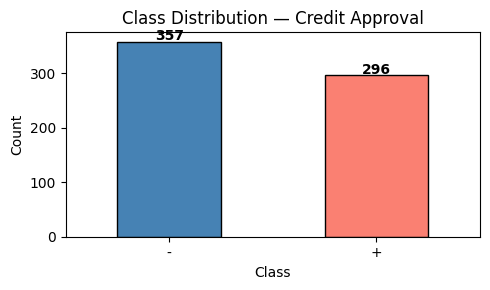

-    357
+    296
Name: count, dtype: int64


In [5]:
# ── Class distribution plot ───────────────────────────────────────────────────
counts = pd.Series(y).map({0: le_target.classes_[0], 1: le_target.classes_[1]}).value_counts()

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
ax.set_title('Class Distribution — Credit Approval')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(counts.index, rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(counts)

---
## Part 2 — Classifier Comparison

In [6]:
# ── Define the five classifiers ───────────────────────────────────────────────
models = {
    'Linear Classifier' : Perceptron(max_iter=1000, random_state=SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Gaussian NB'        : GaussianNB(),
    'Neural Network'     : MLPClassifier(hidden_layer_sizes=(64,),
                                         max_iter=500, random_state=SEED),
}

# ── Evaluation protocol: 10-fold CV × 100 repeats ────────────────────────────
rkf = RepeatedKFold(n_splits=10, n_repeats=100, random_state=SEED)

part2_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=rkf,
                             scoring='accuracy', n_jobs=-1)
    part2_results[name] = (scores.mean(), scores.std())
    print(f"{name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}")

Linear Classifier     mean=0.8090  std=0.0621
Logistic Regression   mean=0.8675  std=0.0401
KNN                   mean=0.8636  std=0.0396
Gaussian NB           mean=0.8028  std=0.0451
Neural Network        mean=0.8612  std=0.0402


In [7]:
# ── Part 2 Results Table ──────────────────────────────────────────────────────
part2_df = pd.DataFrame(
    [(k, f"{v[0]:.4f}", f"{v[1]:.4f}") for k, v in part2_results.items()],
    columns=['Algorithm', 'Mean Accuracy', 'Std']
)
print("\nPart 2 — All Features")
print(part2_df.to_string(index=False))


Part 2 — All Features
          Algorithm Mean Accuracy    Std
  Linear Classifier        0.8090 0.0621
Logistic Regression        0.8675 0.0401
                KNN        0.8636 0.0396
        Gaussian NB        0.8028 0.0451
     Neural Network        0.8612 0.0402


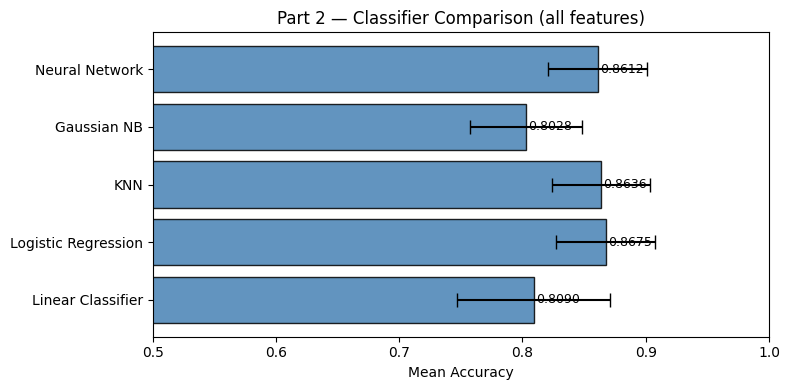

In [8]:
# ── Part 2 Bar Chart ─────────────────────────────────────────────────────────
names   = list(part2_results.keys())
means   = [part2_results[n][0] for n in names]
stds    = [part2_results[n][1] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, means, xerr=stds, color='steelblue',
               edgecolor='black', capsize=5, alpha=0.85)
ax.set_xlabel('Mean Accuracy')
ax.set_title('Part 2 — Classifier Comparison (all features)')
ax.set_xlim(0.5, 1.0)
for bar, m in zip(bars, means):
    ax.text(m + 0.002, bar.get_y() + bar.get_height()/2,
            f'{m:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('part2_comparison.png', dpi=150)
plt.show()

---
## Part 3 — Feature Selection

In [9]:
# ── Strategy: Forward Selection via SequentialFeatureSelector ─────────────────
# With m=15 features, exhaustive search requires 2^15 - 1 = 32,767 subsets.
# Each subset needs 1,000 CV rounds → ~33 million evaluations: impractical.
# Forward selection reduces this to O(m^2) ≈ 120 evaluations per algorithm.
#
# Note: we use n_repeats=10 (instead of 100) inside SFS to keep runtime
# reasonable while still stabilising the selection criterion.
# The final evaluation of the selected subset still uses n_repeats=100.

sfs_cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=SEED)
final_cv = RepeatedKFold(n_splits=10, n_repeats=100, random_state=SEED)

part3_results = {}

for name, model in models.items():
    print(f"\nRunning forward selection for: {name}")
    sfs = SequentialFeatureSelector(
        estimator=model,
        n_features_to_select='auto',  # stops when adding a feature stops helping
        direction='forward',
        scoring='accuracy',
        cv=sfs_cv,
        n_jobs=-1,
    )
    sfs.fit(X_scaled, y)
    selected_mask = sfs.get_support()
    selected_names = [feature_names[i] for i, s in enumerate(selected_mask) if s]
    X_sel = X_scaled[:, selected_mask]

    # Final evaluation with full 100-repeat protocol
    scores = cross_val_score(model, X_sel, y, cv=final_cv,
                             scoring='accuracy', n_jobs=-1)
    part3_results[name] = {
        'features' : selected_names,
        'n'        : len(selected_names),
        'mean'     : scores.mean(),
        'std'      : scores.std(),
    }
    print(f"  Selected ({len(selected_names)}): {selected_names}")
    print(f"  mean={scores.mean():.4f}  std={scores.std():.4f}")


Running forward selection for: Linear Classifier
  Selected (7): ['A1', 'A3', 'A5', 'A6', 'A7', 'A8', 'A11']
  mean=0.8124  std=0.0764

Running forward selection for: Logistic Regression
  Selected (7): ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']
  mean=0.8664  std=0.0412

Running forward selection for: KNN
  Selected (7): ['A1', 'A2', 'A3', 'A4', 'A7', 'A11', 'A13']
  mean=0.8809  std=0.0387

Running forward selection for: Gaussian NB
  Selected (7): ['A4', 'A6', 'A7', 'A9', 'A10', 'A11', 'A15']
  mean=0.8711  std=0.0402

Running forward selection for: Neural Network
  Selected (7): ['A1', 'A4', 'A5', 'A6', 'A7', 'A11', 'A12']
  mean=0.8733  std=0.0401


In [10]:
# ── Part 3 Results Table ──────────────────────────────────────────────────────
rows = []
for name, r in part3_results.items():
    rows.append({
        'Algorithm'         : name,
        'Best Feature Subset': ', '.join(r['features']),
        '# Features'        : r['n'],
        'Mean Accuracy'     : f"{r['mean']:.4f}",
        'Std'               : f"{r['std']:.4f}",
    })

part3_df = pd.DataFrame(rows)
print("\nPart 3 — Feature Selection Results")
print(part3_df.to_string(index=False))


Part 3 — Feature Selection Results
          Algorithm           Best Feature Subset  # Features Mean Accuracy    Std
  Linear Classifier   A1, A3, A5, A6, A7, A8, A11           7        0.8124 0.0764
Logistic Regression    A1, A2, A3, A4, A5, A6, A7           7        0.8664 0.0412
                KNN  A1, A2, A3, A4, A7, A11, A13           7        0.8809 0.0387
        Gaussian NB A4, A6, A7, A9, A10, A11, A15           7        0.8711 0.0402
     Neural Network  A1, A4, A5, A6, A7, A11, A12           7        0.8733 0.0401


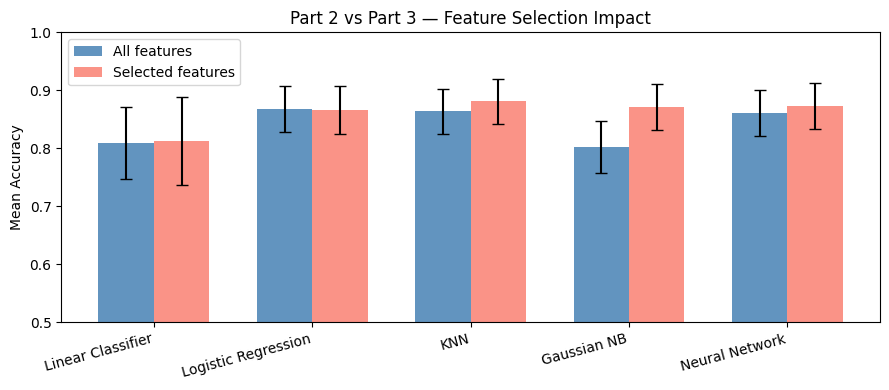

In [11]:
# ── Part 2 vs Part 3 Comparison Chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(models))
width = 0.35

means_all = [part2_results[n][0] for n in models]
stds_all  = [part2_results[n][1] for n in models]
means_sel = [part3_results[n]['mean'] for n in models]
stds_sel  = [part3_results[n]['std']  for n in models]

ax.bar(x - width/2, means_all, width, yerr=stds_all,
       label='All features', color='steelblue', capsize=4, alpha=0.85)
ax.bar(x + width/2, means_sel, width, yerr=stds_sel,
       label='Selected features', color='salmon', capsize=4, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()), rotation=15, ha='right')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Part 2 vs Part 3 — Feature Selection Impact')
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('part3_comparison.png', dpi=150)
plt.show()

In [12]:
# ── Print combined summary ────────────────────────────────────────────────────
print(f"{'Algorithm':<22} {'P2 Mean':>8} {'P2 Std':>7}  {'P3 Mean':>8} {'P3 Std':>7}  {'Δ Mean':>8}")
print("-" * 68)
for name in models:
    m2, s2 = part2_results[name]
    m3     = part3_results[name]['mean']
    s3     = part3_results[name]['std']
    delta  = m3 - m2
    print(f"{name:<22} {m2:>8.4f} {s2:>7.4f}  {m3:>8.4f} {s3:>7.4f}  {delta:>+8.4f}")

Algorithm               P2 Mean  P2 Std   P3 Mean  P3 Std    Δ Mean
--------------------------------------------------------------------
Linear Classifier        0.8090  0.0621    0.8124  0.0764   +0.0034
Logistic Regression      0.8675  0.0401    0.8664  0.0412   -0.0010
KNN                      0.8636  0.0396    0.8809  0.0387   +0.0174
Gaussian NB              0.8028  0.0451    0.8711  0.0402   +0.0682
Neural Network           0.8612  0.0402    0.8733  0.0401   +0.0121
